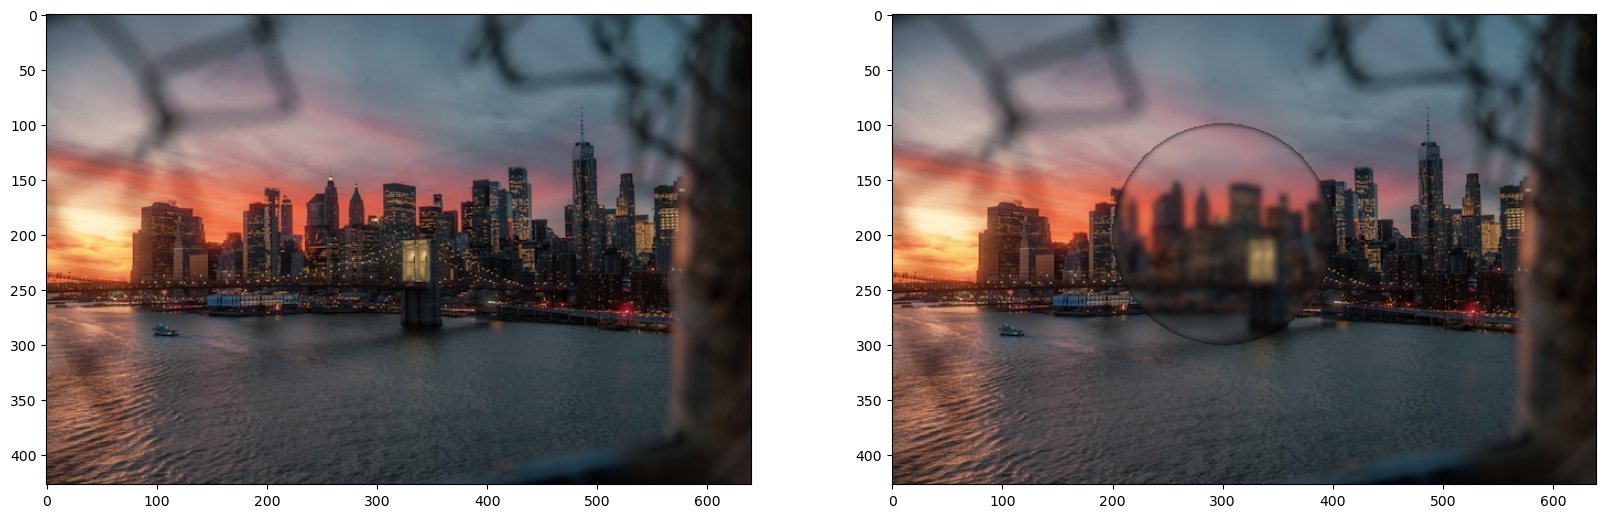

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoqueROI(img, centro, x,y):
    img1 = np.copy(img)
    valx,valy = centro
    mediox = x//2
    medioy = y//2
    mascara = np.zeros_like(img,dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediox,medioy),0,0,360,(255,255,255),-1)
    img_mask = cv2.bitwise_and(img,mascara)
    desenfoque = cv2.GaussianBlur(img_mask,(15,15),0)
    img1[mascara!=0] = desenfoque[mascara!=0]
    return img1

imgo1 = cv2.imread("fondo.jpg")
imggray = cv2.cvtColor(imgo1,cv2.COLOR_BGR2RGB)
final1 = desenfoqueROI(imggray,(300,200),200,200)

fig,axs = plt.subplots(1,2,figsize=(20,20))

axs[0].imshow(imggray)
axs[1].imshow(final1)

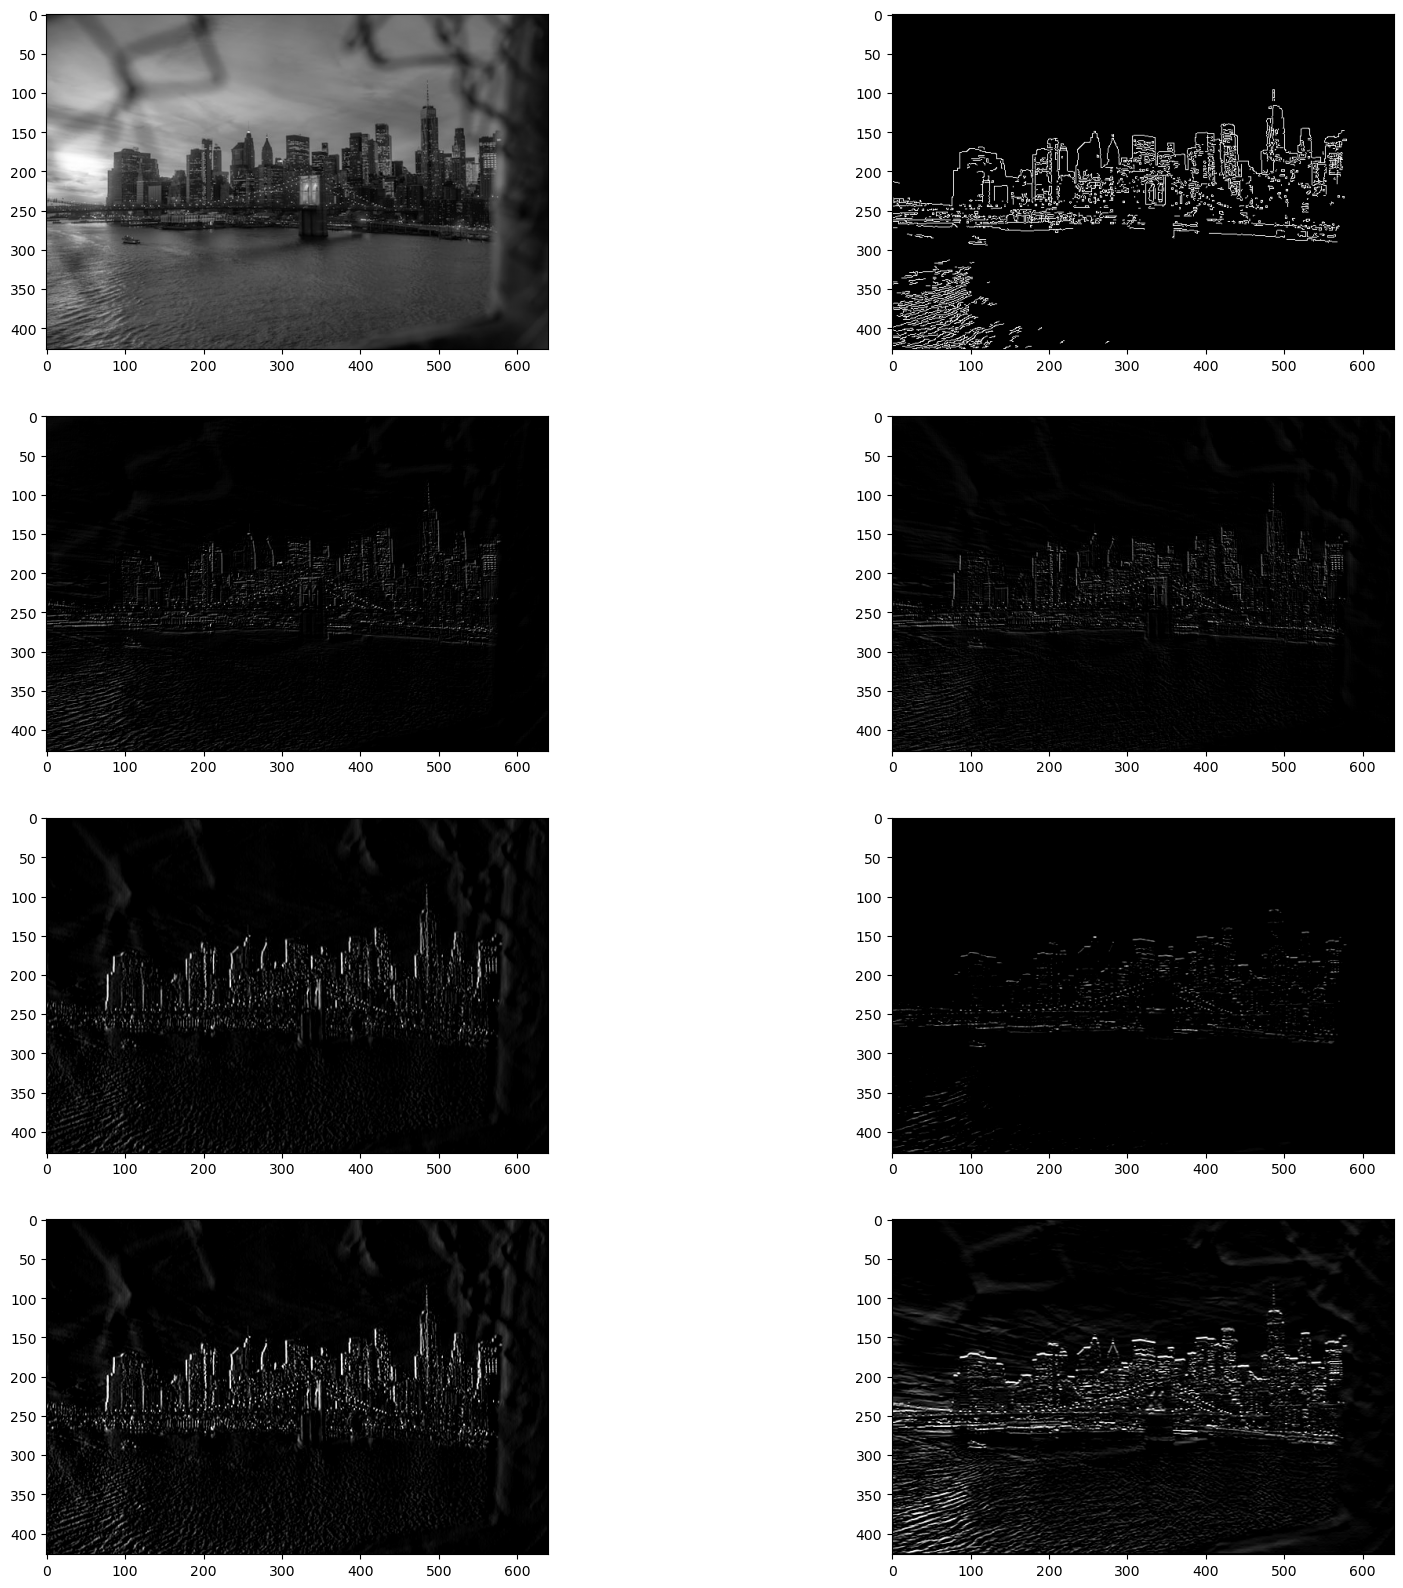

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgo1 = cv2.imread("fondo.jpg")
imggray = cv2.cvtColor(imgo1,cv2.COLOR_BGR2GRAY)

# filtro Roberts
# Kernel 
robertsx = np.array([[-1,0],[0,1]])
robertsy = np.array([[0,-1],[1,0]])

img_robx = cv2.filter2D(imggray, -1, robertsx)
img_roby = cv2.filter2D(imggray, -1, robertsy)

rob_gmagnitud = np.sqrt(img_robx**2+img_roby**2)
rob_gsireccion = np.arctan2(img_roby,img_robx) # Simulando aplicar un filtro prewitt

# filstro prewitt
# kernels
prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
prewitty = np.array([[1,1,0],[0,0,0],[-1,-1,-1]])

img_prx = cv2.filter2D(imggray, -1, prewittx)
img_pry = cv2.filter2D(imggray, -1, prewitty)

prew_mag = np.sqrt(prewittx**2+prewitty**2)
prew_dir = np.arctan2(prewitty,prewittx)

# filtro sobel
# kernel
sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

img_sobx = cv2.filter2D(imggray, -1, sobelx)
img_soby = cv2.filter2D(imggray, -1, sobely)

sob_mag = np.sqrt(sobelx**2+sobely**2)
sob_dir = np.arctan2(sobely,sobelx)

# filtro Canny
canny = cv2.Canny(imggray, 100,200)

fig,axs = plt.subplots(4,2,figsize=(20,20))

axs[0][0].imshow(imggray, cmap="gray")
axs[0][1].imshow(canny, cmap="gray")
axs[1][0].imshow(img_robx, cmap="gray")
axs[1][1].imshow(img_roby, cmap="gray")
axs[2][0].imshow(img_prx, cmap="gray")
axs[2][1].imshow(img_pry, cmap="gray")
axs[3][0].imshow(img_sobx, cmap="gray")
axs[3][1].imshow(img_soby, cmap="gray")

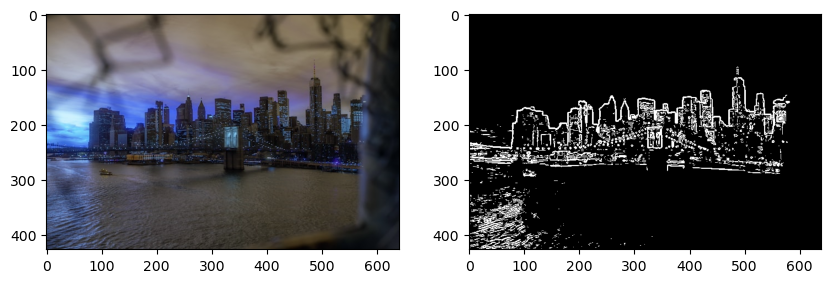

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def robberts_mejorado(imagen):
    imagen_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)

    suavizado= cv2.GaussianBlur(imagen_gray,(3,3),0)
    kernelx=np.array([[-2,0],[0,2]],dtype=np.float32)
    kernely=np.array([[0,2],[-2,0]],dtype=np.float32)
    robx=cv2.filter2D(suavizado,cv2.CV_16S,kernelx) #CV_16S trabajar con 16 bits
    roby=cv2.filter2D(suavizado,cv2.CV_16S,kernely) #CV_16S trabajar con 16 bits

    roberts=cv2.addWeighted(np.abs(robx),0.7,np.abs(roby),0.7,0)
    #resaltar las los bordes

    _,borders=cv2.threshold(roberts,30,255,cv2.THRESH_BINARY)
    return borders


img= cv2.imread("fondo.jpg")
img_final=robberts_mejorado(img)

fig,axs = plt.subplots(1,2,figsize=(10,10))

axs[0].imshow(img, cmap="gray")
axs[1].imshow(img_final , cmap='gray')

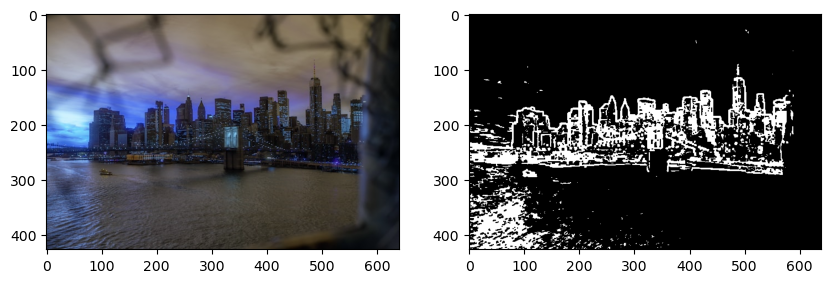

In [19]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejorado(imagen,tam_kernel=3,umbral=30):
    img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    img_gray=cv2.GaussianBlur(img_gray,(3,3),0)

    sobelx=cv2.Sobel(img_gray,cv2.CV_64F,1,0,ksize=tam_kernel)
    sobely=cv2.Sobel(img_gray,cv2.CV_64F,0,1,ksize=tam_kernel)

    magnitud=np.sqrt(sobelx**2 + sobely**2)

    magnitud=cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _,border=cv2.threshold(magnitud,umbral,255,cv2.THRESH_BINARY) #agrageamos OTSU

    kernel_morf=np.ones((2,2),np.uint8)
    border=cv2.morphologyEx(border,cv2.MORPH_CLOSE,kernel_morf)
    return border

img= cv2.imread("fondo.jpg")
img_final=sobel_mejorado(img)

fig,axs = plt.subplots(1,2,figsize=(10,10))

axs[0].imshow(img, cmap="gray")
axs[1].imshow(img_final , cmap='gray')

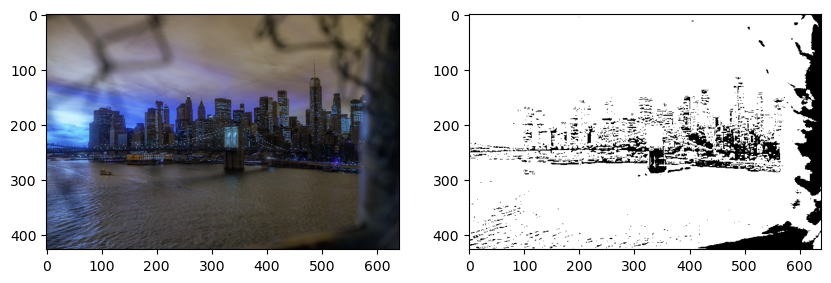

In [42]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def prewit_mejorado(imagen):
    img_gray=cv2.cvtColor(imagen,cv2.COLOR_BGR2GRAY)
    img_gray=cv2.GaussianBlur(img_gray,(3,3),0)

    prewittx=np.array([[1,0,-1],[1,0,-1],[1,0,-1]],dtype=np.float32)
    prewitty=np.array([[1,0,1],[0,0,0],[-1,-1,-1]],dtype=np.float32)

    x=cv2.filter2D(img_gray,cv2.CV_64F,prewittx)
    y=cv2.filter2D(img_gray,cv2.CV_64F,prewitty)

    magnitud= np.sqrt(x**2+y**2)
    _,border=cv2.threshold(magnitud,30,255,cv2.THRESH_BINARY)
    return border

img= cv2.imread("fondo.jpg")
img_final=prewit_mejorado(img)

fig,axs = plt.subplots(1,2,figsize=(10,10))

axs[0].imshow(img, cmap="gray")
axs[1].imshow(img_final , cmap='gray')

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# filtro Roberts
# Kernel 
def mRobert(imggray):
    robertsx = np.array([[-1,0],[0,1]])
    robertsy = np.array([[0,-1],[1,0]])

    img_robx = cv2.filter2D(imggray, -1, robertsx)
    img_roby = cv2.filter2D(imggray, -1, robertsy)

    rob_gmagnitud = np.sqrt(img_robx**2+img_roby**2)
    rob_gsireccion = np.arctan2(img_roby,img_robx) # Simulando aplicar un filtro prewitt
    return (img_robx,img_roby)
# filstro prewitt
# kernels
def mPrewitt(imggray):
    prewittx = np.array([[1,0,-1],[1,0,-1],[1,0,-1]])
    prewitty = np.array([[1,1,0],[0,0,0],[-1,-1,-1]])

    img_prx = cv2.filter2D(imggray, -1, prewittx)
    img_pry = cv2.filter2D(imggray, -1, prewitty)

    prew_mag = np.sqrt(prewittx**2+prewitty**2)
    prew_dir = np.arctan2(prewitty,prewittx)
    return (img_prx,img_pry)

# filtro sobel
# kernel
def mSobel(imggray):
    sobelx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
    sobely = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])

    img_sobx = cv2.filter2D(imggray, -1, sobelx)
    img_soby = cv2.filter2D(imggray, -1, sobely)

    sob_mag = np.sqrt(sobelx**2+sobely**2)
    sob_dir = np.arctan2(sobely,sobelx)
    return (img_sobx,img_soby)

Text(0.5, 1.0, 'Sobel Mejorado')

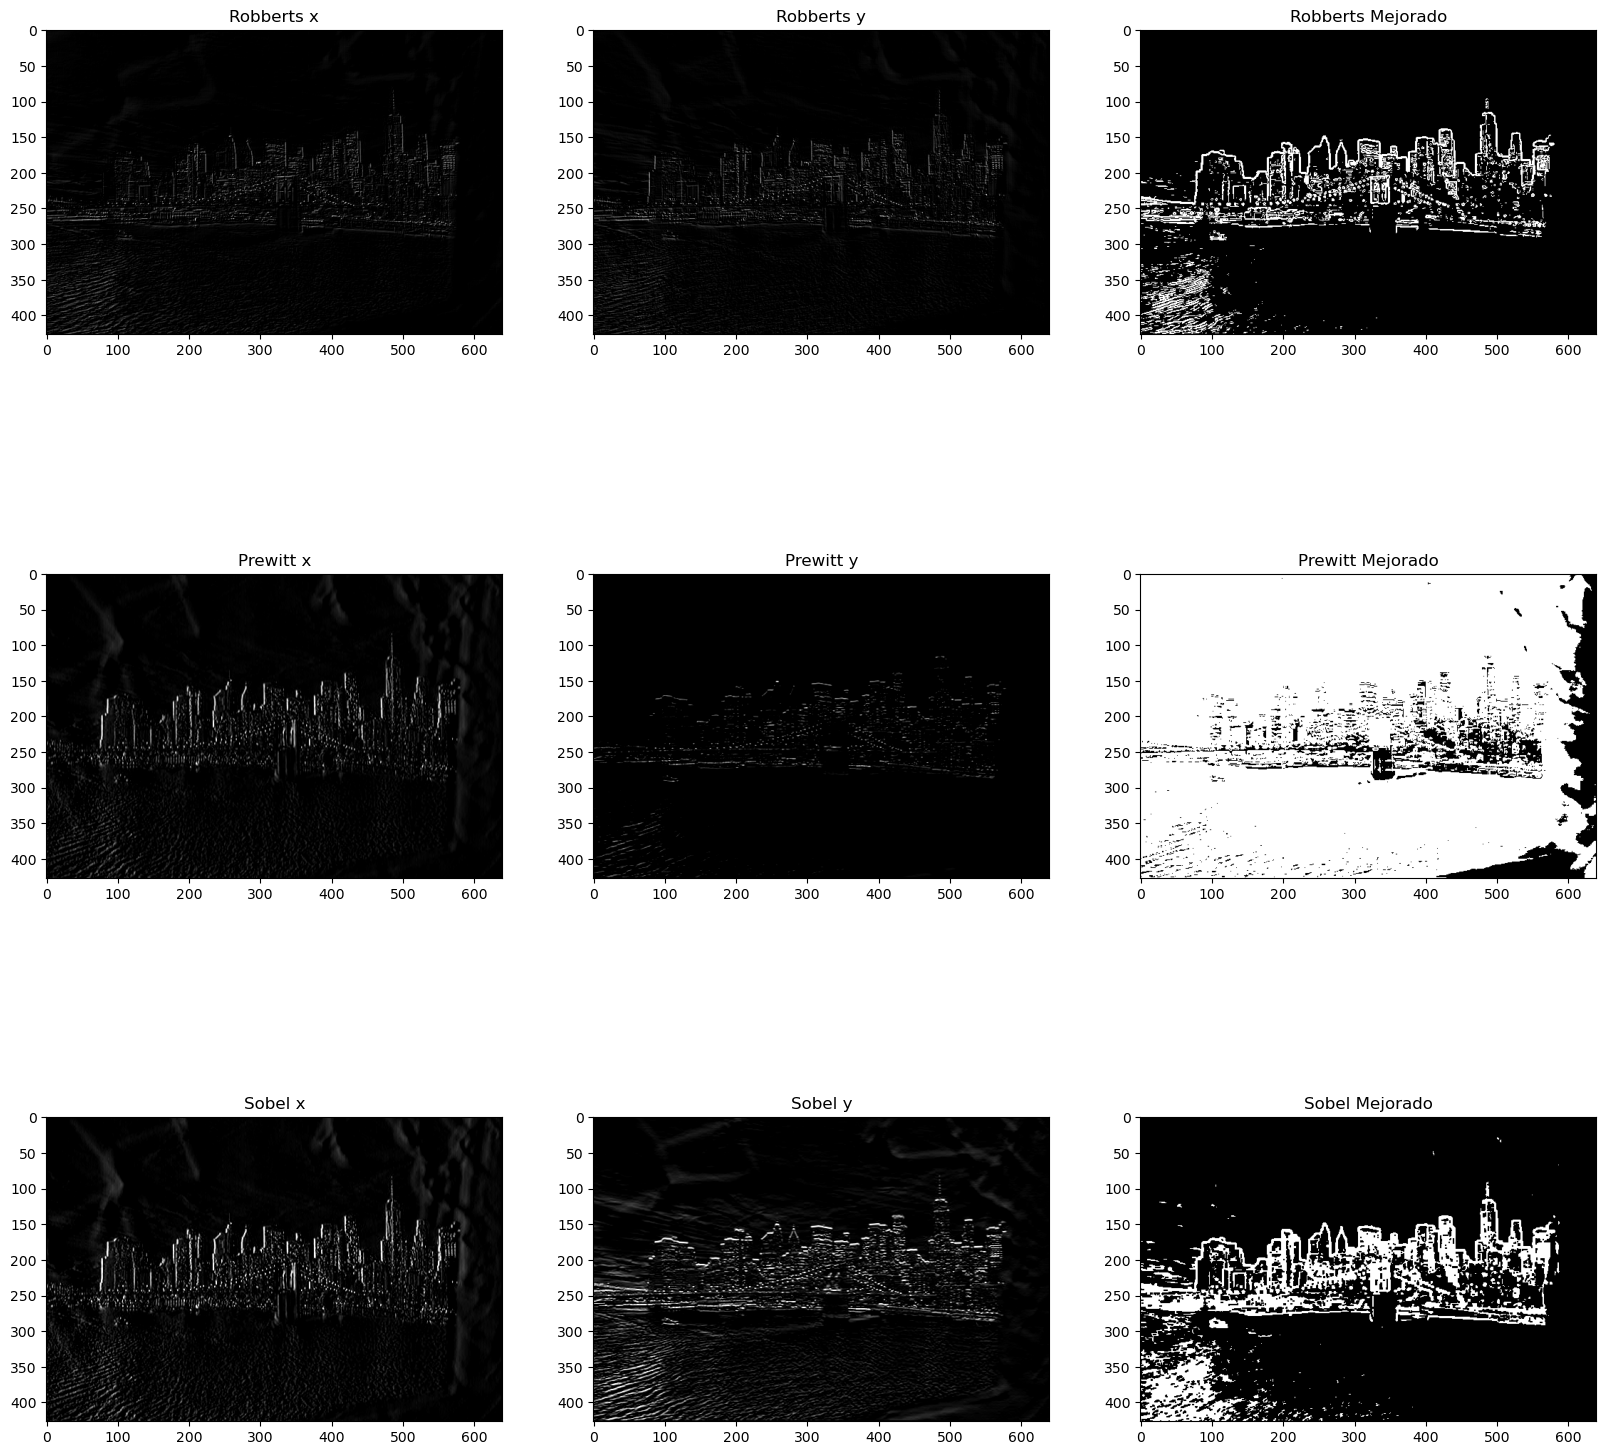

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img= cv2.imread("fondo.jpg")
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

rob1,rob2 = mRobert(img_gray)
rob3 = robberts_mejorado(img)

pw1,pw2 = mPrewitt(img_gray)
pw3 = prewit_mejorado(img)

sob1,sob2 = mSobel(img_gray)
sob3 = sobel_mejorado(img)

fig,axs = plt.subplots(3,3,figsize=(20,20))

axs[0][0].imshow(rob1, cmap="gray")
axs[0][0].set_title("Robberts x")
axs[0][1].imshow(rob2, cmap="gray")
axs[0][1].set_title("Robberts y")
axs[0][2].imshow(rob3, cmap="gray")
axs[0][2].set_title("Robberts Mejorado")
axs[1][0].imshow(pw1, cmap="gray")
axs[1][0].set_title("Prewitt x")
axs[1][1].imshow(pw2, cmap="gray")
axs[1][1].set_title("Prewitt y")
axs[1][2].imshow(pw3, cmap="gray")
axs[1][2].set_title("Prewitt Mejorado")
axs[2][0].imshow(sob1, cmap="gray")
axs[2][0].set_title("Sobel x")
axs[2][1].imshow(sob2, cmap="gray")
axs[2][1].set_title("Sobel y")
axs[2][2].imshow(sob3, cmap="gray")
axs[2][2].set_title("Sobel Mejorado")